<a href="https://colab.research.google.com/github/EnricoCeci/Master-Data-Science---Profession-AI---Portfolio-/blob/main/Classification_Model_Cross-Selling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Insurance Cross-Selling**

**AssurePredict** is a leading insurance company specializing in innovative risk management solutions. This project aims to build a predictive model capable of identifying cross-selling opportunities among existing customers by determining which clients are most likely to be interested in purchasing an additional vehicle insurance policy.

## Project Objective

The goal is to develop a **machine learning model** that predicts whether customers who currently hold a health insurance policy would be interested in purchasing a vehicle insurance policy.

The model will help AssurePredict improve the effectiveness of its cross-selling strategies and increase market penetration.

### Added Value for AssurePredict

* Increase the conversion rate of vehicle insurance sales.
* Optimize marketing campaigns by targeting customers who are more likely to purchase an additional policy.
* Reduce the costs associated with ineffective marketing campaigns through more accurate customer targeting.

---

# Dataset

The dataset (available here: [https://proai-datasets.s3.eu-west-3.amazonaws.com/insurance_cross_sell.csv](https://proai-datasets.s3.eu-west-3.amazonaws.com/insurance_cross_sell.csv)) contains detailed information about customers and their insurance-related behavior.

The main features of the dataset are:

* **id:** Unique customer identifier.
* **Gender:** Customer's gender.
* **Age:** Customer's age.
* **Driving_License:** 1 if the customer holds a valid driver's license, 0 otherwise.
* **Region_Code:** Unique code representing the customer's region of residence.
* **Previously_Insured:** 1 if the customer already has vehicle insurance, 0 otherwise.
* **Vehicle_Age:** Age of the customer's vehicle.
* **Vehicle_Damage:** 1 if the customer has previously experienced vehicle damage or accidents, 0 otherwise.
* **Annual_Premium:** Annual insurance premium paid by the customer.
* **PolicySalesChannel:** Sales channel through which the policy was purchased (e.g., email, phone, in person).
* **Vintage:** Number of days the customer has been insured with AssurePredict.
* **Response:** 1 if the customer accepted the cross-selling offer, 0 otherwise.

---

# Required Tasks

## 1. Dataset Exploration

A preliminary exploration of the dataset will help better understand the distribution of both the features and the target variable. In particular, you should analyze:

* The distribution of the **Response** variable to identify any imbalance between customers who accepted and those who rejected the cross-selling offer.
* The relationships between key variables such as **Annual_Premium**, **Vehicle_Age**, **Previously_Insured**, and the customer's response.

### Added Value

A thorough exploratory data analysis helps uncover hidden patterns and critical insights that can significantly influence the performance of the predictive model.

---

## 2. Handling Class Imbalance

The target variable **Response** may be imbalanced, with considerably more customers rejecting the offer than accepting it.

To address this issue, you should consider techniques such as:

* **Class Weights:** Assign a higher penalty to the majority class during model training.
* **Oversampling or Undersampling:** Create a more balanced dataset to improve the model's ability to generalize.

### Added Value

Properly handling class imbalance is essential to avoid models with a high false negative rate, thereby improving the effectiveness of cross-selling predictions.

---

## 3. Building the Predictive Model

Using machine learning algorithms, build a model capable of predicting the probability that a customer will respond positively to a cross-selling offer.

### Added Value

The predictive model will enable AssurePredict to accurately identify customers who are most likely to purchase an additional insurance policy, thereby improving the return on investment of its marketing campaigns.

---

# Points of Attention

Pay close attention to the class distribution. Refer to the recommended reading on class imbalance.

If the classes are imbalanced, consider one or more of the following approaches:

* Penalize the majority class using the **class_weight** parameter.
* Apply **oversampling** or **undersampling** techniques (see the referenced article).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import RocCurveDisplay
from imblearn.over_sampling import RandomOverSampler

In [9]:
# DATASET IMPORT

df = pd.read_csv("https://proai-datasets.s3.eu-west-3.amazonaws.com/insurance_cross_sell.csv")

df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [3]:
# ASSESSMENT TYPE OF FEATURES AND PRESENCE OF NULL VALUES

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


##**Data Preprocessing**

In [10]:
# ONE HOT ENCODING: "Gender"

df = pd.get_dummies(df,columns=["Gender"])
df.head()

,id,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Gender_Female,Gender_Male
0,1,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1,False,True
1,2,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0,False,True
2,3,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1,False,True
3,4,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0,False,True
4,5,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0,True,False


In [11]:
# LABEL ENCODING: "Vehicle_Age"

vehicle_age_mapping = {"< 1 Year":0, "1-2 Year":1, "> 2 Years":2}
df["Vehicle_Age"] = df["Vehicle_Age"].map(vehicle_age_mapping)
df.head()

,id,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Gender_Female,Gender_Male
0,1,44,1,28.0,0,2,Yes,40454.0,26.0,217,1,False,True
1,2,76,1,3.0,0,1,No,33536.0,26.0,183,0,False,True
2,3,47,1,28.0,0,2,Yes,38294.0,26.0,27,1,False,True
3,4,21,1,11.0,1,0,No,28619.0,152.0,203,0,False,True
4,5,29,1,41.0,1,0,No,27496.0,152.0,39,0,True,False


In [12]:
# LABEL ENCODING: "Vehicle_Damage"

vehicle_damage_mapping = {"No":0, "Yes":1}
df["Vehicle_Damage"] = df["Vehicle_Damage"].map(vehicle_damage_mapping)
df.head()

,id,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Gender_Female,Gender_Male
0,1,44,1,28.0,0,2,1,40454.0,26.0,217,1,False,True
1,2,76,1,3.0,0,1,0,33536.0,26.0,183,0,False,True
2,3,47,1,28.0,0,2,1,38294.0,26.0,27,1,False,True
3,4,21,1,11.0,1,0,0,28619.0,152.0,203,0,False,True
4,5,29,1,41.0,1,0,0,27496.0,152.0,39,0,True,False


In [ ]:
# COUNT OF 0s AND 1s FOR "Response"

"""
Analysis of the "Response" variable distribution to identify potential class imbalances between customers who accept (1s) and those who reject (0s) the cross-selling offer.
"""

counts = df["Response"].value_counts()
counts

,count
Response,
0,334399
1,46710




Only 12.25% of customers accepted the vehcle insurance cross-selling offer.
87.75% did not.

Clear imbalance between the two classes.

##**Exploratory Data Analysis (EDA)**

###Univariate Analysis

Contingency tables are used to explore the relationship between the target variable e categorical features, while boxplots are used to analyse the relationship between the target variable and quantitative features.

In [ ]:
# NORMALIZED RELATIONSHIP BETWEEN "Vehicle_Age" AND "Response"

pd.crosstab(
    df["Vehicle_Age"],
    df["Response"],
    normalize="index"
).round(2)

Response,0,1
Vehicle_Age,,
0,0.96,0.04
1,0.83,0.17
2,0.71,0.29


The results show that as the vehicle age increases the number of customers accepting the vehicle insurance cross-selling offer increases as well.

In [ ]:
# RELATIONSHIP BETWEEN "Previously_Insured" E "Response"

pd.crosstab(
    df["Previously_Insured"],
    df["Response"]
)

Response,0,1
Previously_Insured,,
0,159929,46552
1,174470,158


In [ ]:
# NORMALIZED RELATIONSHIP BETWEEN "Previously_Insured" E "Response"


pd.crosstab(
    df["Previously_Insured"],
    df["Response"],
    normalize="index"
).round(4)


Response,0,1
Previously_Insured,,
0,0.7745,0.2255
1,0.9991,0.0009


The results show that only a really small share of  customers who already have an insured vehicle accept the cross-selling offer.

Almost all those who accepte the offer don't already have a vehicle insurance.

Customers with "Response" = 1 in the entire dataset = 46,710
Customers with "Previously_Insured" = 0 and "Response" = 1: 46,552
--> 46.552:46.710 = 99.66%.

It is important to note that, although the 46,552 customers account for more than 99% of all customers who accepte the offer, they represent only about 23% of customers without an existing vehicle insurance policy. Therefore, Previously_Insured = 0 appears to be a necessary, but not sufficient, condition for accepting the cross-selling offer.



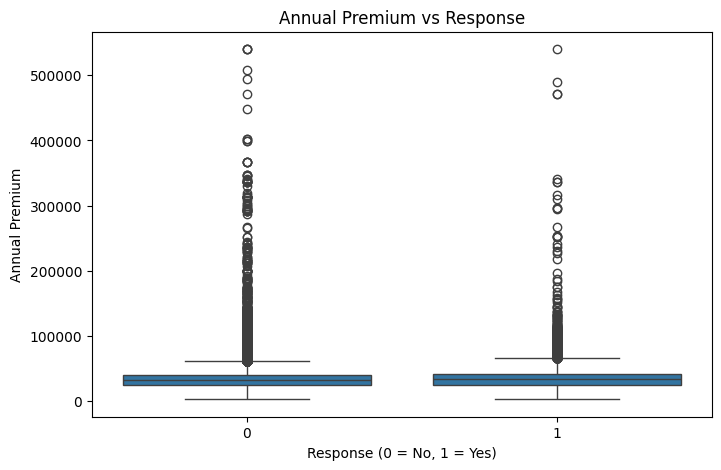

In [ ]:
# RELATIONSHIP BETWEEN "Response" AND "Annual_Premium"

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Response",
    y="Annual_Premium",
    data=df
)

plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Annual Premium")
plt.title("Annual Premium vs Response")

plt.show()


The two boxplots show a substantial overlap in the distribution of the annal premium between customers who accept the cross-selling offer and those who don't. This suggests that the Annual_Premium variable does not exhibit a substantial difference or strong univariate discriminative power with respect to the target variable.  

In [ ]:
# NORMALIZED RELATIONSHIP BETWEEN "Driving_License" AND "Response"

pd.crosstab(
    df["Driving_License"],
    df["Response"],
    normalize="index"
).round(4)

Response,0,1
Driving_License,,
0,0.9495,0.0505
1,0.8773,0.1227


The data show that approximately 95% of customers without a driving license don't accept the cross-selling offer.

The proportion of customers who accepte the offer is more than twice as high among customers with a driving license as among those without one, but still relatively low.

Although "Driving_License" is associated with the target variable, its univariate discriminative power remains limited.

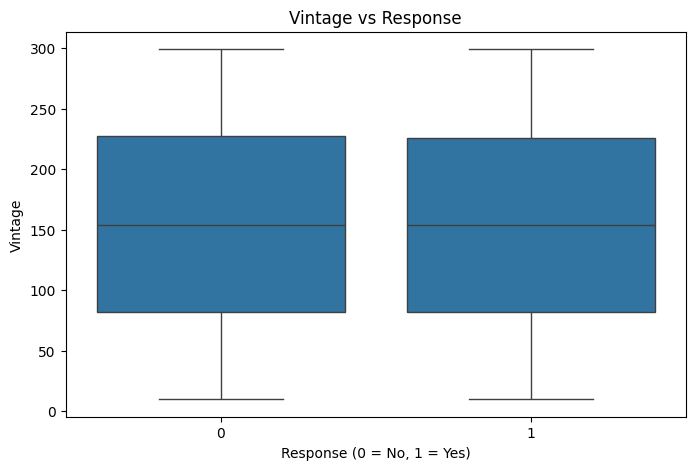

In [ ]:
# RELATIONSHIP BETWEEN "Vintage" AND "Response"

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Response",
    y="Vintage",
    data=df
)

plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Vintage")
plt.title("Vintage vs Response")

plt.show()

Customer loyalty doesn't appear to have a significant influence on the likelihood of accepting the cross-selling offer.

The boxplots are almost identical, therefore the hypothesis that longe-term customers may be more willing to accept the offer is not evident in the data.

In [ ]:
# RELATIONSHIP BETWEEN "Vehicle_Damage" AND "Response"

pd.crosstab(
    df["Vehicle_Damage"],
    df["Response"],
    normalize="index"
).round(2)

Response,0,1
Vehicle_Damage,,
0,0.99,0.01
1,0.76,0.24


Having previously experienced car accidents or damages is associated to a significantly higher likelihood of accepting the offer compared with custmoers who havent (approximately 24% agaisnt 1%). However, the majority of customers with a history of vehicle damage don't accept the offer, indicating that the discriminative power of the variable is relatively strong but is not sufficient on its own to explain acceptance.

In [ ]:
# NORMALIZED RELATIONSHIP BETWEEN "Region_Code" AND "Response"

pd.crosstab(
    df["Region_Code"],
    df["Response"],
    normalize="index"
).round(2)

Response,0,1
Region_Code,,
0.0,0.91,0.09
1.0,0.89,0.11
2.0,0.93,0.07
3.0,0.87,0.13
4.0,0.84,0.16
5.0,0.88,0.12
6.0,0.93,0.07
7.0,0.87,0.13
8.0,0.90,0.10


Data don't indicate a strong discriminative power of this feature.

The acceptance rates are quite homogeneous across the regions, with limited variations and none of them exhibits acceptance levels significantly higher or lower.

In [ ]:
# TOP 10 SALES CHANNELS PER CUSTOMER REACHED

"""
Identification of the sales channels with the highest number of contacted customers.
"""

counts = df["Policy_Sales_Channel"].value_counts().head(10)
counts

,count
Policy_Sales_Channel,
152.0,134784
26.0,79700
124.0,73995
160.0,21779
156.0,10661
122.0,9930
157.0,6684
154.0,5993
151.0,3885


In [ ]:
# NORMALIZED RELATIONSHIP BETWEEN TOP 10 "Policy_Sales_Channel" AND "Response"

channels = [152.0, 26.0, 124.0, 160.0, 156.0, 122.0, 157.0, 154.0, 151.0, 163.0]

df_sub = df[df["Policy_Sales_Channel"].isin(channels)]

pd.crosstab(
    df_sub["Policy_Sales_Channel"],
    df_sub["Response"],
    normalize="index"
).round(2)


Response,0,1
Policy_Sales_Channel,,
26.0,0.80,0.20
122.0,0.83,0.17
124.0,0.81,0.19
151.0,0.97,0.03
152.0,0.97,0.03
154.0,0.75,0.25
156.0,0.78,0.22
157.0,0.73,0.27
160.0,0.98,0.02


Focusing on the subset of sales channels that reached more than 350,000 customers (350,394), a clear distinction emerges between channels with an acceptance rate close to 0% and channels with substantially higher acceptance rates, ranging from approximately 17% to a maximum of 30%.

This feature appears to be informative from a predictive perspective. However, its causal interpretation is less straightforward. Given the marketing context, it is plausible that the choice of sales channel reflects a prior customer segmentation strategy rather than representing a direct driver of customers' decisions.

In [ ]:
# NORMALIZED RELATIONSHIP BETWEEN "Gender_Female" AND "Response"

pd.crosstab(
    df["Gender_Female"],
    df["Response"],
    normalize="index"
).round(2)

Response,0,1
Gender_Female,,
False,0.86,0.14
True,0.90,0.10


The data show limited acceptance rates for both genders, without a significant difference between the two and no discriminative power for the feature.

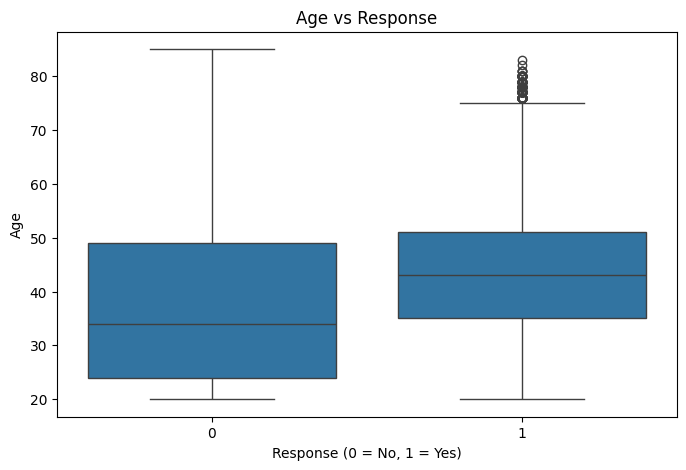

In [ ]:
# RELATIONSHIP BETWEEN "Age" AND "Response"

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Response",
    y="Age",
    data=df
)

plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.title("Age vs Response")

plt.show()

In [ ]:
df.groupby("Response")["Age"].median()

,Age
Response,
0,34.0
1,43.0


The data show that customers who accepted the cross-selling offer have a median age that is 9 years higher than those who did not (43 vs. 34 years).

This suggests that older customers are more likely to accept the cross-selling offer and that age contributes to differentiating the two groups on average, although there is still substantial overlap between their distributions.

### Univariate Analisys - Key Findings

The features most strongly associated with Response are:

- Previously_Insured, with exhibits the highest association, which shows that almost none of the customers with a vehicle insurance accept the cross-selling offer whereas the share of the customers without a previous vehicle insurance that accept the offer account fot nearly all customers that accept the cross-selling offer (46,552 out of 46,710 = 99.66%)

- Vehicle_Age, for which the acceptance rate increases as vehicle age increases.

- Vehicle_Damage, which shows that only 1% of customers with no history of car damage accept the offer, while the share increases approximately up to 24% among those with past car damages;

- Age, that shows that median age of accepting customers is 9 years higher than the age of customers who don't accept (43 vs 34), indicating a positive association between age and willingness to accept the offer, although the distributions still exhibit substantial overlap.

The remaining features do not exhibit sufficiently pronounced differences to indicate a meaningful association with the target variable.

##**Multivariate Analysis**

The following analysis examines the relationship between the "Vehicle_Age", "Vehicle_Damage", and "Age" features and the target variable "Response", conditional on the "Previously_Insured" feature.

"Previously_Insured" was chosen because it indicates whether customers already have a vehicle insurance or not, which is exactly the product AssurePredict Aims to cross-seel. Moreover the EDA showed that this feature exhibits the strongest association with the target variable, as more than 99% of customers who accepted the cross-selling offer do not already have vehicle insurance.

Furthermore, since the data show that the acceptance rate among customers with "Previously_Insured" = 1 is negligible (less than 0.1%), the conditional analysis is restricted to customers with "Previously_Insured" = 0.

Conditioning on "Previously_Insured" = 0 makes it possible to investigate, within the subgroup of customers who do not already have vehicle insurance, which factors distinguish customers who accepted the cross-selling offer from those who did not.

In [ ]:
# RELATIONSHIP BETWEEN "Vehicle_Age" AND "Response" CONDITIONING ON "Previously_Insured"

pd.crosstab(
    df[df["Previously_Insured"] == 0]["Vehicle_Age"],
    df[df["Previously_Insured"] == 0]["Response"],
    normalize="index"
).round(2)



Response,0,1
Vehicle_Age,,
0,0.87,0.13
1,0.74,0.26
2,0.71,0.29


The results are consistent with those of the previous unconditional analysis. However, by conditioning on "Previously_Insured" = 0, the relationship is examined exclusively within the subgroup of customers who are potentially more interested in the cross-selling offer, effectively removing the influence of customers who already have vehicle insurance.

In [ ]:
# RELATIONSHIP BETWEEN "Vehicle_Damage" AND "Response" CONDITIONING ON "Previously_Insured"

pd.crosstab(
    df[df["Previously_Insured"] == 0]["Vehicle_Damage"],
    df[df["Previously_Insured"] == 0]["Response"],
    normalize="index"
).round(2)

Response,0,1
Vehicle_Damage,,
0,0.96,0.04
1,0.75,0.25


Also in this case the results are consistent with what observed in the unconditional analysis.

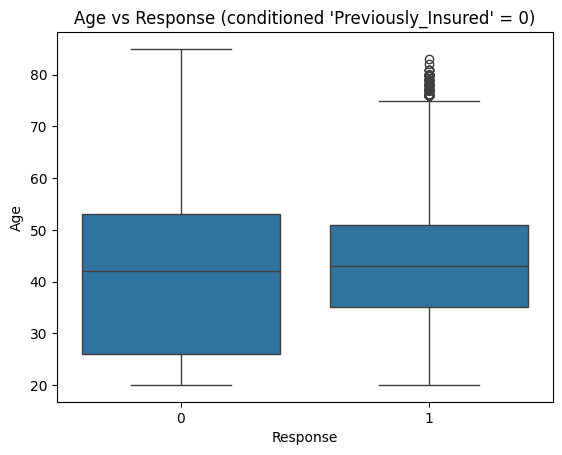

In [ ]:
# RELATIONSHIP BETWEEN "Age" AND "Response" CONDITIONING ON "Previously_Insured"

sns.boxplot(
    x="Response",
    y="Age",
    data=df[df["Previously_Insured"] == 0]
)

plt.title("Age vs Response")
plt.ylabel("Age")
plt.title("Age vs Response (conditioned 'Previously_Insured' = 0)")

plt.show()

Unlike the overall analysis, this plot shows that, once the analysis is restricted to customers without existing vehicle insurance, age no longer clearly distinguishes between those who accept the cross-selling offer and those who do not.

In other words, among customers who are equally eligible for the offer, age no longer discriminates between respondents and non-respondents. The clear separation observed in the overall analysis disappears, suggesting that it is not a direct effect of age.

A plausible explanation is that younger customers are, on average, more likely to already have vehicle insurance and therefore belong predominantly to the group that does not accept the cross-selling offer, whereas older customers are more likely to be uninsured and thus belong more frequently to the group that accepts the offer. This suggests that the apparent effect of age is largely explained by its relationship with Previously_Insured, which appears to be the underlying structural variable.

Indeed, after conditioning on Previously_Insured = 0, the effect of age essentially disappears: both groups have nearly the same median age (42–43 years), which corresponds to the median age observed for Response = 1 in the overall box plot.

###Multivariate Analysis - Key Findings

The multivariate analysis confirms the relationships identified in the univariate analysis between "Vehicle_Age", "Vehicle_Damage", and the target variable. Both features retain their predictive value even after controlling for "Previously_Insured", which emerges as the underlying structural variable in the dataset.

"Vehicle_Age" shows a progressive increase in the probability of accepting the cross-selling offer, while "Vehicle_Damage" is associated with a higher propensity to accept the offer. However, neither feature is sufficient on its own to fully explain customer acceptance.

In contrast, the relationship between "Age" and "Response" observed in the univariate analysis is not confirmed. Instead, "Age" appears to reflect its association with "Previously_Insured" rather than with the target variable itself, as evidenced by the disappearance of the age effect after conditioning on "Previously_Insured".

Overall, this analysis makes it possible to distinguish between features with a direct association with the target ("Vehicle_Age" and "Vehicle_Damage") and features whose apparent effect ("Age") is mediated by other customer characteristics.


##**Model Development**

In [ ]:
df.head()

,id,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Gender_Female,Gender_Male
0,1,44,1,28.0,0,2,1,40454.0,26.0,217,1,False,True
1,2,76,1,3.0,0,1,0,33536.0,26.0,183,0,False,True
2,3,47,1,28.0,0,2,1,38294.0,26.0,27,1,False,True
3,4,21,1,11.0,1,0,0,28619.0,152.0,203,0,False,True
4,5,29,1,41.0,1,0,0,27496.0,152.0,39,0,True,False


###Model Development - Application of "class_weight="balanced"" and the Default Decision Threshold (0.5)

In [13]:
# Extraction of the feature and target arrays

# Feature array
X = df.drop(columns=["id", "Response"]).to_numpy()

# Target array
y = df["Response"].to_numpy()

In [14]:
# train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, stratify = y)

In [6]:
X_train.shape

(266776, 10)

In [7]:
X_test.shape

(114333, 10)

In [15]:
# Data Standardization

# Instantiate a StandardScaler object
ss = StandardScaler()

# TRAIN_SET standardization
X_train = ss.fit_transform(X_train)

# TEST_SET standardization
X_test = ss.transform(X_test)

In [16]:
# Regression Model
lr = LogisticRegression(class_weight="balanced")

# Training of the model
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [17]:
# Predictions for training and test sets and predicted class probabilities for each observation

y_pred_train = lr.predict(X_train)
y_proba_train = lr.predict_proba(X_train)
y_pred_test = lr.predict(X_test)
y_proba_test = lr.predict_proba(X_test)

In [18]:
# Function for confusion matrix

def plot_confusion_matrix(y_true, y_pred, labels=["Negative", "Positive"], show_precision_recall=True):

  cm = confusion_matrix(y_true, y_pred) # tn, fp, fn, tp

  df_cm = pd.DataFrame(cm, index = labels,
                    columns = ["Predicted "+labels[0],"Predicted "+labels[1]])

  sns.heatmap(df_cm, annot=True, fmt='g')

  if show_precision_recall:

    # Precision (% pos classifications truly pos)
    plt.text(0, -0.1, f"Precision: {(cm[1][1]/(cm[1][1]+cm[0][1])):.3f}")

    # Precision (% pos observation classified as pos)
    plt.text(1, -0.1, f"Recall: {(cm[1][1]/(cm[1][1]+cm[1][0])):.3f}")

In [19]:
# Classification report - TRAIN_SET

print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.99      0.59      0.74    234079
           1       0.25      0.98      0.40     32697

    accuracy                           0.64    266776
   macro avg       0.62      0.78      0.57    266776
weighted avg       0.90      0.64      0.70    266776



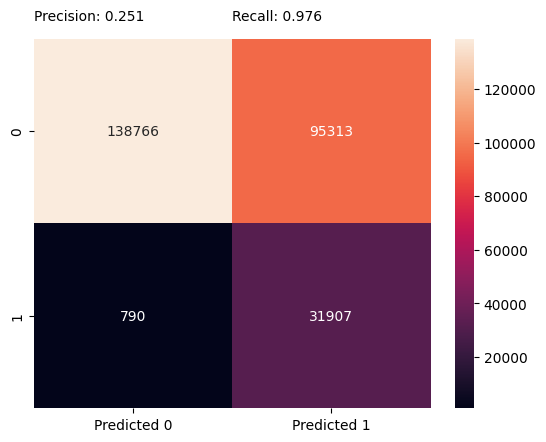

In [20]:
# Confusion Matrix - TRAIN_SET

plot_confusion_matrix(y_train, y_pred_train, ["0", "1"])

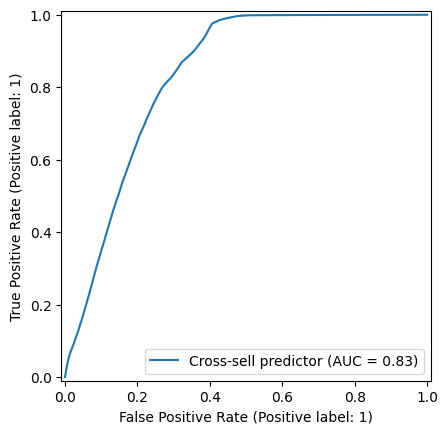

In [21]:
# AUC - TRAIN_SET

RocCurveDisplay.from_estimator(lr, X_train, y_train, name = "Cross-sell predictor")
plt.show()

In [22]:
# Classification report - TEST_SET

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.99      0.59      0.74    100320
           1       0.25      0.98      0.40     14013

    accuracy                           0.64    114333
   macro avg       0.62      0.78      0.57    114333
weighted avg       0.90      0.64      0.70    114333



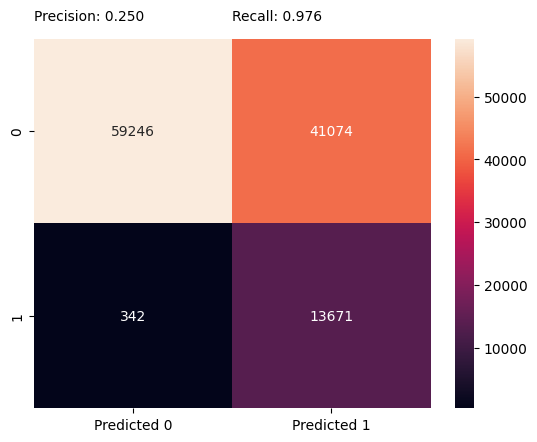

In [23]:
# Calcolo la Confusion Matrix - TEST_SET

plot_confusion_matrix(y_test, y_pred_test, ["0", "1"])

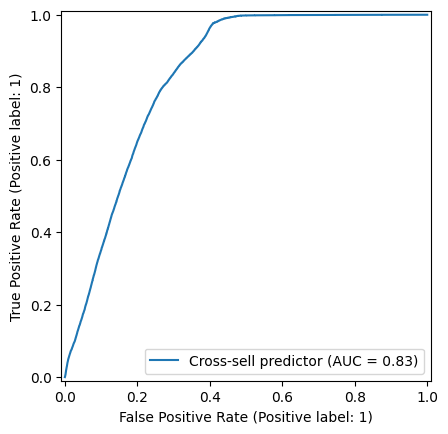

In [ ]:
# AUC - TEST_SET

RocCurveDisplay.from_estimator(lr, X_test, y_test, name = "Cross-sell predictor")
plt.show()

###Key Findings - Application of "class_weight="balanced"" and the Default Decision Threshold (0.5)

The first point to highlight is that the model's performance does not deteriorate from the training set to the test set. This is evident in terms of AUC, precision, and recall, suggesting that the model does not suffer from overfitting.

The model achieves an AUC of 0.83, indicating a good ability to discriminate between customers who are likely to accept the cross-selling offer and those who are not.

The confusion matrix also suggests that the default decision threshold of 0.5 is an appropriate choice, given the recall achieved and the relatively small number of positive observations compared with the overall size of the dataset.

These results are even more encouraging considering that the model is intended to support a cross-selling strategy, where the primary objective is to identify and convert as many potentially interested customers as possible. In this context, minimizing the number of false negatives (customers who are actually interested but are not identified by the model) is particularly important. In other words, once the model is deployed, the cost of contacting a customer who ultimately turns out not to be interested (a false positive) is lower than the cost of failing to identify a customer who is more likely to accept the offer (a false negative).

This indicates that the class imbalance in favor of the negative class has been effectively compensated for by using the class_weight="balanced" parameter.

However, the model exhibits low precision due to a relatively high number of false positives. This issue will be addressed by increasing the decision threshold.


###Model Development - Application of "class_weight="balanced"" and the Higher Decision Threshold (0.75)

Raise the threshold up to 0.75 trying to reduce False Positives

In [24]:
# All observations with a prob. > 0.75 are classified as Positive - TRAIN_SET

y_pred_train = np.where(y_proba_train[:,1]>0.75, 1, 0)

In [25]:
# Classification report - TRAIN_SET

print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91    234079
           1       0.33      0.29      0.31     32697

    accuracy                           0.84    266776
   macro avg       0.61      0.60      0.61    266776
weighted avg       0.83      0.84      0.84    266776



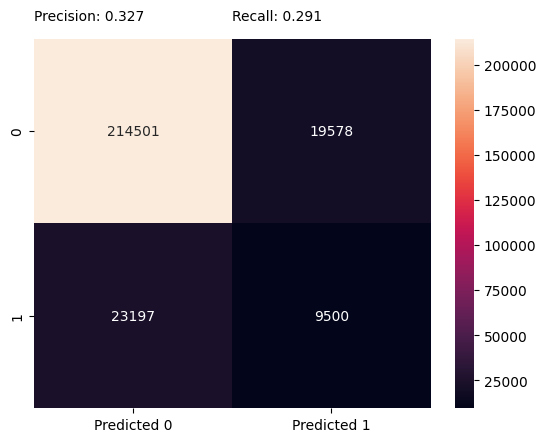

In [26]:
# Confusion Matrix - TRAIN_SET

plot_confusion_matrix(y_train, y_pred_train, ["0", "1"])

In [27]:
# All observations with a prob. > 0.75 are classified as Positive - TEST_SET

y_pred_test = np.where(y_proba_test[:,1]>0.75, 1, 0)

In [28]:
# Classification Report - TEST_SET

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91    100320
           1       0.33      0.29      0.31     14013

    accuracy                           0.84    114333
   macro avg       0.62      0.60      0.61    114333
weighted avg       0.83      0.84      0.84    114333



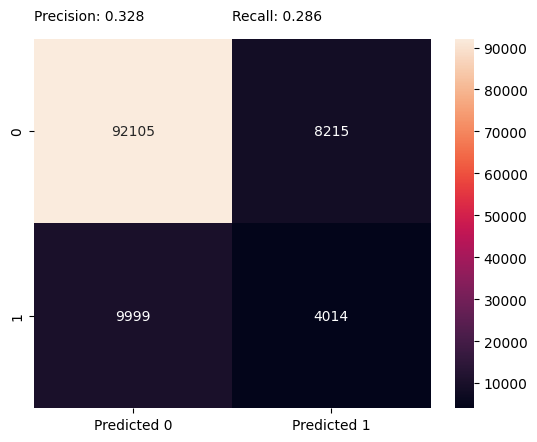

In [29]:
# Confusion Matrix - TEST_SET

plot_confusion_matrix(y_test, y_pred_test, ["0", "1"])

###Key Findings - Application of "class_weight="balanced"" and the Higher Decision Threshold (0.75)

Such a high decision threshold is not appropriate, as recall drops substantially (from the previous value of 0.98 to below 0.30) due to a significant increase in the number of false negatives, which now become the predominant outcome among the actual positive observations.

In a cross-selling context, this represents a critical drawback. Once the model is deployed to make predictions on new customers, failing to identify a customer who is more likely to accept the offer is more costly than contacting a customer who ultimately turns out not to be interested.

Although precision improves, the gain is relatively modest compared with the substantial loss in recall. Considering the primary objective of the cross-selling strategy, the resulting trade-off is therefore unfavorable.

###Model Development - Application of "class_weight="balanced"" and the Lower Decision Threshold (0.25)

Lower the threshold to 0.25 trying to reduce False Negatives

In [30]:
# All observations with a prob. > 0.25 are classified as Positive - TRAIN_SET

y_pred_train = np.where(y_proba_train[:,1]>0.25, 1, 0)

In [31]:
# Classification Report - TRAIN_SET

print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      0.57      0.73    234079
           1       0.24      0.98      0.39     32697

    accuracy                           0.62    266776
   macro avg       0.62      0.78      0.56    266776
weighted avg       0.90      0.62      0.69    266776



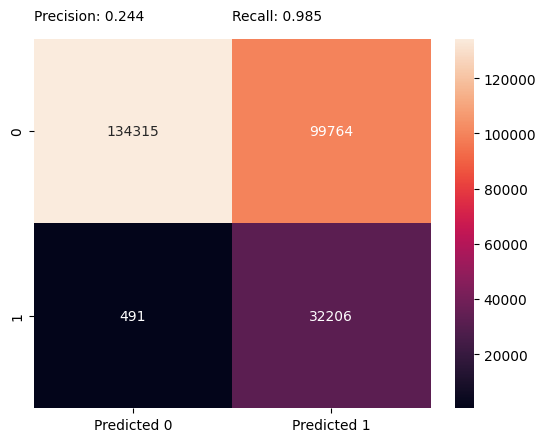

In [32]:
# Confusion Matrix - TRAIN_SET

plot_confusion_matrix(y_train, y_pred_train, ["0", "1"])

In [33]:
# All observations with a prob. > 0.25 are classified as Positive - TEST_SET

y_pred_test = np.where(y_proba_test[:,1]>0.25, 1, 0)

In [34]:
# Classification Report - TEST_SET

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.57      0.73    100320
           1       0.24      0.98      0.39     14013

    accuracy                           0.62    114333
   macro avg       0.62      0.78      0.56    114333
weighted avg       0.90      0.62      0.69    114333



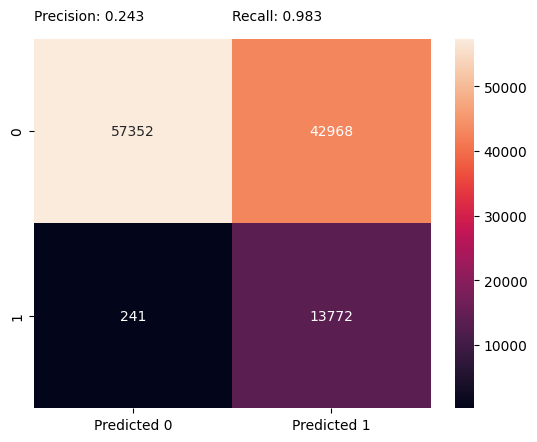

In [35]:
# Confusion Matrix - TEST_SET

plot_confusion_matrix(y_test, y_pred_test, ["0", "1"])

Key Findings - Application of "class_weight="balanced"" and the Lower Decision Threshold (0.25)

Compared with the model using the default decision threshold (0.5), the results do not show any substantial improvement. The gain in recall is offset by the corresponding loss in precision.

This suggests that the majority of positive observations are already identified with a threshold of 0.5, while further lowering the decision threshold recovers only a small additional proportion of true positives at the cost of a significant increase in false positives. This indicates that the positive observations missed at the 0.5 threshold are assigned considerably lower predicted probabilities, making a further reduction of the threshold of limited practical value.

###Model Development - Application of Oversampling

In [36]:
# Oversampling

oversample = RandomOverSampler(sampling_strategy=0.5)

X_over, y_over = oversample.fit_resample(X_train, y_train)

The oversampling strategy was applied only to the training set, with the objective of obtaining a 2:1 ratio between the negative and positive classes, whereas the original class distribution consisted of 87.75% negative cases and 12.25% positive cases.

The intention was to preserve the predominance of the negative class while reducing the degree of class imbalance, thereby maintaining a distribution that still reflects the original data but with less pronounced proportions.

In [37]:
# Data Standardization

# Instantiate a StandardScaler object
ss = StandardScaler()

# TRAIN_OVERSAMPLED_SET standardization
X_over= ss.fit_transform(X_over)

# TEST_SET standardization
X_test = ss.transform(X_test)

In [38]:
# Regression Model
lr = LogisticRegression()

# Training of the model
lr.fit(X_over, y_over)

LogisticRegression()

In [39]:
# Predictions for training and test sets and predicted class probabilities for each observation
y_pred_over = lr.predict(X_over)
y_proba_over = lr.predict_proba(X_over)
y_pred_test = lr.predict(X_test)
y_proba_test = lr.predict_proba(X_test)


In [40]:
# Classification Report - TRAIN_OVERSAMPLED_SET

print(classification_report(y_over, y_pred_over))

              precision    recall  f1-score   support

           0       0.86      0.76      0.81    234079
           1       0.61      0.75      0.67    117039

    accuracy                           0.75    351118
   macro avg       0.73      0.75      0.74    351118
weighted avg       0.77      0.75      0.76    351118



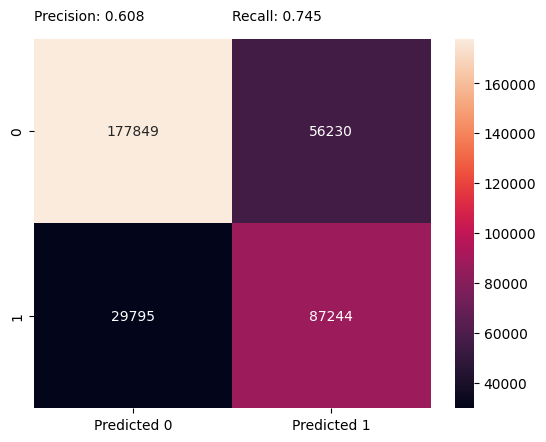

In [41]:
# Confusion Matrix - TRAIN_OVERSAMPLED_SET

plot_confusion_matrix(y_over, y_pred_over, ["0", "1"])

In [42]:
# Classification Report - TEST_SET

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.96      0.76      0.85    100320
           1       0.30      0.74      0.43     14013

    accuracy                           0.76    114333
   macro avg       0.63      0.75      0.64    114333
weighted avg       0.87      0.76      0.79    114333



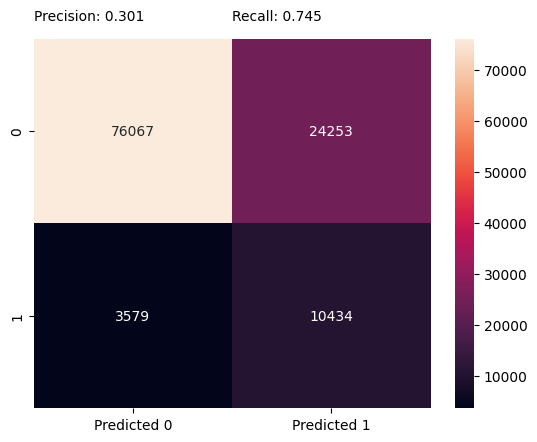

In [43]:
# Confusion Matrix - TEST_SET

plot_confusion_matrix(y_test, y_pred_test, ["0", "1"])

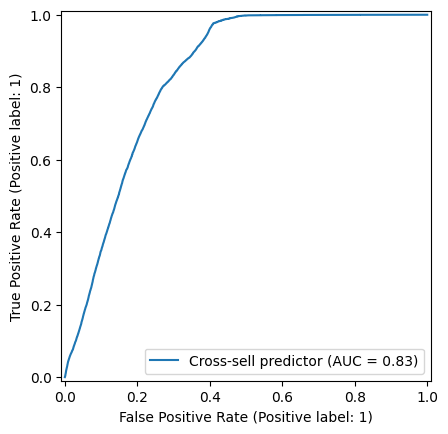

In [44]:
# AUC - TEST_SET

RocCurveDisplay.from_estimator(lr, X_test, y_test, name = "Cross-sell predictor")
plt.show()

###Key Findings - Application of Oversampling


The application of oversampling proves to be less effective than using the class_weight="balanced" parameter in addressing class imbalance.

Although the number of false positives decreases, this improvement comes at the cost of a substantial reduction in the model's ability to correctly classify positive observations. As a result, recall drops considerably, reaching values lower than those obtained with decision thresholds of 0.25 and 0.5.

Un esito di questo tipo non risulta inaspettato alla luce della capacità del modello di distinguere fra osservazioni positive e negative già solo applicando il ribilanciamento dei pesi come testimoniato dai risultati precedenti nonostante il numero esiguo di osservazioni positive. In tale contesto, l’oversampling non apporta un contributo informativo aggiuntivo sufficiente a migliorare le prestazioni complessive del modello.

This outcome is not unexpected. The previous results already showed that the model was able to effectively discriminate between positive and negative observations by using class weight rebalancing alone, despite the relatively small number of positive observations. In this context, oversampling does not provide a meaningful performance improvement, beyond what is already achieved through class-weight rebalancing.


##**Conclusions**

Based on the exploratory analysis and the results obtained during the modeling phase, the recommended model for predicting customers who are likely to accept the cross-selling offer is a logistic regression model using the class_weight="balanced" parameter and the default decision threshold of 0.5.

This configuration effectively compensates for the class imbalance (12.25% positive vs. 87.75% negative cases) while maintaining a high ability to identify customers who are potentially interested in the cross-selling offer, as demonstrated by the high recall values achieved on both the training and test sets, with no evidence of overfitting. Furthermore, the stable AUC of approximately 0.83 indicates that the model has good discriminative ability in distinguishing between customers who are likely to accept the offer and those who are not.

Neither adjustments to the decision threshold nor the application of oversampling technique resulted in an overall improvement in model performance. This indicates that the model based solely on class-weight rebalancing provides the best trade-off between predictive performance and model robustness for the problem considered.

From a business perspective, this configuration is particularly well suited to cross-selling applications, where the primary objective is to minimize the risk of failing to identify potentially interested customers, even at the cost of contacting a larger number of customers who ultimately do not accept the offer.